Project Report
Context-Aware Bowling Rating System for The Hundred
1. Introduction
Traditional bowling evaluation metrics such as economy rate, wickets, and strike rate often fail to capture the context and pressure under which a bowler performs. This limitation becomes more pronounced in modern formats like The Hundred, where matches are constrained by balls instead of overs, and game momentum can shift rapidly.

This project aims to design a context-aware bowling rating system for The Hundred that evaluates bowlers based on impact, pressure creation, phase difficulty, and role responsibility, using ball-by-ball data sourced from Cricsheet.

2. Objective
The objectives of this project are:

To build a bowling performance rating beyond average and economy

To adapt metrics specifically for The Hundred format

To quantify pressure, control, and clutch performance

To present insights through clear, explainable visualizations

3. Data Description
Source: Cricsheet (ball-by-ball data)

Granularity: One row per ball

Match Type: The Hundred (100 balls per innings)

Key Fields Used:
ball, bowler, runs_off_bat, extras, wides, noballs, player_dismissed, innings

All computations are performed at ball level, avoiding over-based assumptions.

4. Methodology & Metrics
4.1 Phase Classification (Hundred-Specific)
The innings is divided into three phases:

Powerplay: Balls 1–25

Middle Phase: Balls 26–80

Death Phase: Balls 81–100

This allows performance to be evaluated relative to match situation difficulty.

4.2 Wicket Impact Score (WIS)
Purpose:
To measure not just how many wickets a bowler took, but when they took them.

Logic:
Wickets are weighted by phase:

Powerplay → 1.2

Middle → 1.0

Death → 1.3

Interpretation:
A death-over wicket contributes more to the rating than a middle-phase wicket due to higher match pressure.

4.3 Dot Ball Pressure (DBP)
Purpose:
To capture a bowler’s ability to build pressure without taking wickets.

Logic:

Only legal dot balls are considered

Dot balls are phase-weighted (higher weight at the death)

Interpretation:
A bowler with fewer wickets but many high-pressure dot balls can still rate highly.

4.4 Boundary Control Index (BCI)
Purpose:
To measure control and discipline.

Formula:

B
C
I
=
1
−
Boundaries Conceded
Legal Balls Bowled
BCI=1−
Legal Balls Bowled
Boundaries Conceded
​

Interpretation:

Values closer to 1 indicate strong boundary prevention

Especially important in The Hundred due to shorter innings

4.5 Run Pressure Index (RPI)
Purpose:
To evaluate performance relative to match conditions, not absolute runs conceded.

Logic:

Match average runs per ball is computed

Bowler runs per ball is compared against match average

R
P
I
=
(
M
a
t
c
h

R
P
B
−
B
o
w
l
e
r

R
P
B
)
×
B
a
l
l
s

B
o
w
l
e
d
RPI=(Match RPB−Bowler RPB)×Balls Bowled
Interpretation:
Positive RPI indicates the bowler outperformed match conditions.

4.6 Death Overs Difficulty Bonus (DODB)
Purpose:
To reward bowlers trusted with high-pressure death balls.

Logic:

D
O
D
B
=
Death Balls Bowled
Total Balls Bowled
DODB=
Total Balls Bowled
Death Balls Bowled
​

Interpretation:
Identifies specialist death bowlers.

4.7 Innings Difficulty Adjustment (IDI)
Bowling second is inherently harder due to chase pressure.

Bowling first → IDI = 1.0

Bowling second → IDI = 1.15

This ensures fair comparison between roles.

5. Final Bowling Rating Formula
Match Bowling Rating
=
(
20
×
W
I
S
+
15
×
R
P
I
+
10
×
D
B
P
+
10
×
B
C
I
+
5
×
D
O
D
B
)
×
I
D
I
Match Bowling Rating=(20×WIS+15×RPI+10×DBP+10×BCI+5×DODB)×IDI
The weights reflect relative importance of skills in The Hundred format.

6. Visual Analysis & Interpretation
6.1 Match Bowling Rating Leaderboard (Bar Chart)
What it shows:

Overall bowling impact per bowler in the match

Why it matters:
Provides an immediate ranking beyond wickets or economy, summarizing total contribution.

Insight Example:
A bowler with fewer wickets but strong pressure and control can rank above a wicket-taker with loose bowling.

6.2 Component Breakdown (Stacked Bar Chart)
What it shows:

Contribution of WIS, RPI, DBP, BCI, and DODB to the final rating

Why it matters:
Makes the model transparent and explainable.

Insight Example:
One bowler may score high due to wickets, while another scores high due to death-over control.

6.3 Impact Map: Wickets vs Pressure (Scatter Plot)
Axes:

X-axis → Run Pressure Index (RPI)

Y-axis → Wicket Impact Score (WIS)

Bubble size:
Overall match rating

Interpretation:

Top-right → Elite all-round impact

High RPI, low WIS → Control bowler

High WIS, low RPI → Strike bowler

This visualization helps identify bowler roles.

6.4 Death Responsibility Chart
What it shows:

Proportion of death balls bowled by each bowler

Why it matters:
Highlights bowlers trusted in the most difficult phase of the innings.

7. Key Findings
Bowling performance in The Hundred cannot be accurately measured using economy alone.

Contextual metrics reveal hidden contributors who build pressure without taking wickets.

Phase-weighted evaluation provides fairer assessment of bowler impact.

The model is format-aware, explainable, and scalable to tournament level.

8. Conclusion & Future Scope
This project successfully demonstrates a context-aware bowling rating system tailored for The Hundred. The approach is modular and can be extended to:

Tournament-level ratings

Batter-quality-adjusted wickets

Win probability impact

Fielding-linked bowling analysis

Interactive Power BI dashboards

9. Tools Used
Python (Pandas, NumPy, Matplotlib)

Google Colab

Cricsheet ball-by-ball data

Power BI (for dashboard integration)

In [38]:
import pandas as pd
import numpy as np


In [39]:
df=pd.read_csv("/content/1252701.csv")

In [40]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed'],
      dtype='object')

Setup and Preprocessing

In [54]:
# Total runs conceded on each ball
df["total_runs"] = df["runs_off_bat"] + df["extras"]


In The Hundred, only legal balls count toward pressure.Wides & no-balls = no pressure, so excluded.

In [55]:
df["legal_ball"] = (
    df["wides"].isna() & df["noballs"].isna()
).astype(int)


Phase identification

| Phase     | Balls  |
| --------- | ------ |
| Powerplay | 1–25   |
| Middle    | 26–80  |
| Death     | 81–100 |


In [56]:
def get_phase_hundred(ball):
    ball_no = int(ball)
    if ball_no <= 25:
        return "PP"
    elif ball_no <= 80:
        return "Middle"
    else:
        return "Death"

df["phase"] = df["ball"].apply(get_phase_hundred)


Wicket impact score

| Phase  | Weight |
| ------ | ------ |
| PP     | 1.2    |
| Middle | 1.0    |
| Death  | 1.3    |


✔ Rewards clutch wickets, not cheap ones.

In [57]:
df["is_wicket"] = df["player_dismissed"].notna().astype(int)

phase_wicket_weight = {
    "PP": 1.2,
    "Middle": 1.0,
    "Death": 1.3
}

df["wicket_value"] = (
    df["is_wicket"] * df["phase"].map(phase_wicket_weight)
)

WIS = (
    df.groupby("bowler")["wicket_value"]
    .sum()
    .rename("WIS")
)


Dot ball pressure

In [58]:
#Dots create pressure → mistakes
df["dot_ball"] = (
    (df["total_runs"] == 0) &
    (df["legal_ball"] == 1)
).astype(int)

phase_dot_weight = {
    "PP": 1.2,
    "Middle": 1.0,
    "Death": 1.3
}

df["dot_pressure"] = (
    df["dot_ball"] * df["phase"].map(phase_dot_weight)
)

DBP = (
    df.groupby("bowler")["dot_pressure"]
    .sum()
    .rename("DBP")
)


Boundary control index

In [59]:
#Boundaries hurt more in The Hundred.
df["is_boundary"] = df["runs_off_bat"].isin([4,6]).astype(int)

boundary = df.groupby("bowler").agg(
    boundaries=("is_boundary","sum"),
    balls=("legal_ball","sum")
)

boundary["BCI"] = (
    1 - boundary["boundaries"] / boundary["balls"]
)


run pressure index

In [60]:
#Did the bowler beat match conditions?
match_rpb = df["total_runs"].sum() / df["legal_ball"].sum()

bowler_runs = df.groupby("bowler")["total_runs"].sum()
bowler_balls = df.groupby("bowler")["legal_ball"].sum()

bowler_rpb = bowler_runs / bowler_balls

RPI = (
    (match_rpb - bowler_rpb) * bowler_balls
).rename("RPI")
#✔ Positive = bowler applied pressure.

Death over difficulty bonus

In [61]:
#Death bowling = elite skill.
death_balls = (
    df[df["phase"] == "Death"]
    .groupby("bowler")["legal_ball"]
    .sum()
)

DODB = (
    death_balls / bowler_balls
).fillna(0).rename("DODB")


Bowling fist vs second adjustment

In [62]:
#Bowling second in Hundred is harder.
bowling_innings = df["innings"].iloc[0]

IDI = 1.0 if bowling_innings == 1 else 1.15


Final match bowling rating

In [63]:
# Formula (Explainable & Balanced)

Match_Bowling_Rating = (
    20 * WIS +
    15 * RPI +
    10 * DBP +
    10 * boundary["BCI"] +
    5  * DODB
) * IDI


 Final Output Table

In [64]:
result = pd.concat(
    [
        Match_Bowling_Rating.rename("Match_Bowling_Rating"),
        WIS, RPI, DBP,
        boundary["BCI"],
        DODB
    ],
    axis=1
).fillna(0).sort_values(
    "Match_Bowling_Rating",
    ascending=False
)

result


,Match_Bowling_Rating,WIS,RPI,DBP,BCI,DODB
bowler,,,,,,
EA Burns,335.959184,2.4,10.530612,12.0,1.000000,0.0
FR Davies,241.959184,1.2,7.530612,9.6,0.900000,0.0
CE Dean,166.802721,1.2,4.897959,6.0,0.933333,0.0
KL Gordon,163.459184,2.4,1.530612,8.4,0.850000,0.0
DJS Dottin,152.959184,2.4,-1.469388,12.0,0.700000,0.0
DB Sharma,136.459184,1.2,0.530612,9.6,0.850000,0.0
HC Knight,98.979592,1.2,1.265306,4.8,0.800000,0.0
IECM Wong,24.459184,1.2,-4.469388,6.0,0.750000,0.0
AH Maqsood,14.489796,0.0,-0.367347,1.2,0.800000,0.0


Bowling reting leaderboard

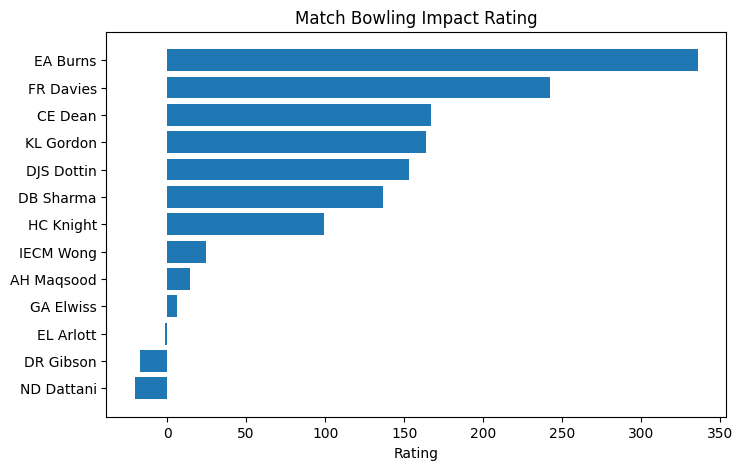

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.barh(result.index, result["Match_Bowling_Rating"])
plt.title("Match Bowling Impact Rating")
plt.xlabel("Rating")
plt.gca().invert_yaxis()
plt.show()


Component Breakdown

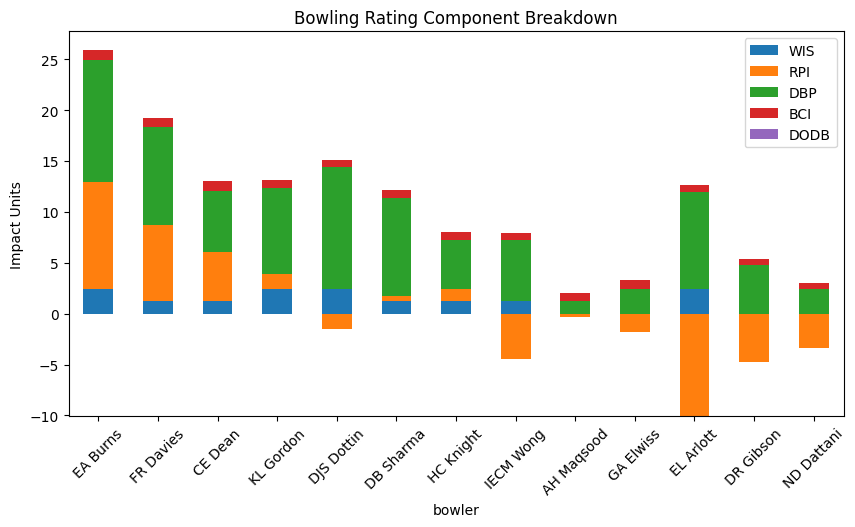

In [66]:
result[["WIS","RPI","DBP","BCI","DODB"]].plot(
    kind="bar", stacked=True, figsize=(10,5)
)
plt.title("Bowling Rating Component Breakdown")
plt.ylabel("Impact Units")
plt.xticks(rotation=45)
plt.show()


Impact map

/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


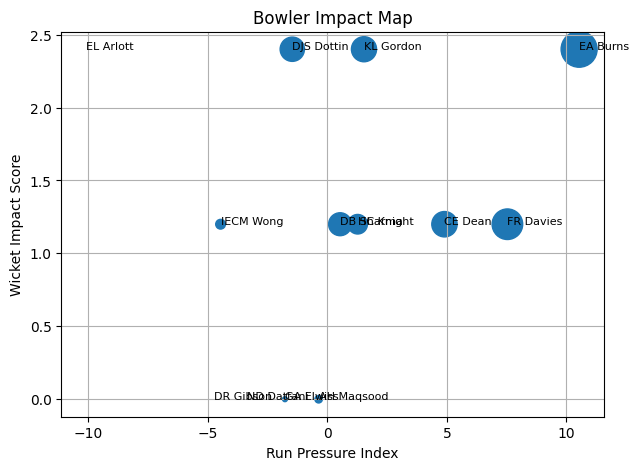

In [67]:
plt.figure(figsize=(7,5))
plt.scatter(result["RPI"], result["WIS"], s=result["Match_Bowling_Rating"]*2)

for i in result.index:
    plt.text(result.loc[i,"RPI"], result.loc[i,"WIS"], i, fontsize=8)

plt.xlabel("Run Pressure Index")
plt.ylabel("Wicket Impact Score")
plt.title("Bowler Impact Map")
plt.grid(True)
plt.show()
